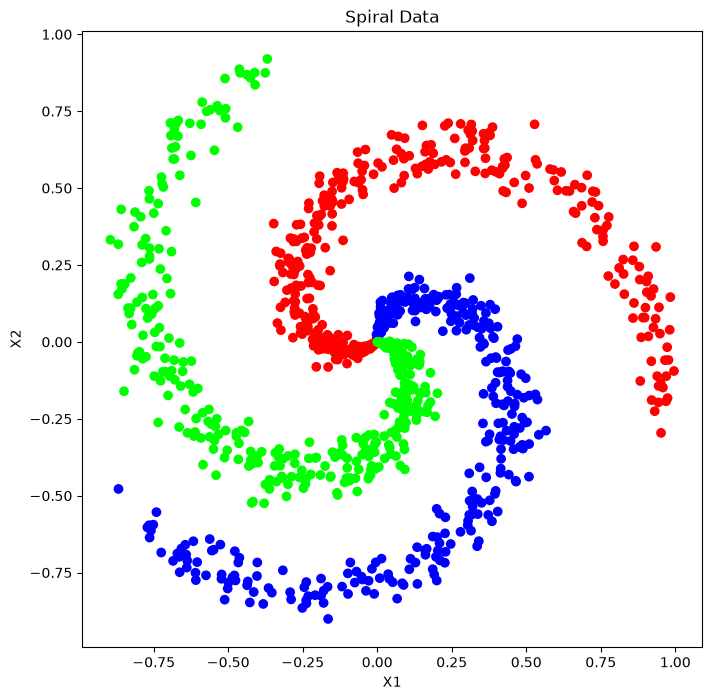

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# function to generate spiral data
def generate_spiral_data(n_points, n_classes):
    X = []
    y = []
    for class_number in range(n_classes):
        ix = range(n_points * class_number, n_points * (class_number +1))
        r = np.linspace(0.0, 1, n_points) # radius
        t = np.linspace(class_number * 4, (class_number + 1) * 4, n_points) + np.random.randn(n_points) * 0.2
        X.extend(np.c_[r * np.sin(t), r * np.cos(t)])
        y.extend([class_number] * n_points)
    return np.array(X), np.array(y)

# General spiral data
X, y = generate_spiral_data(333, 3)

#Plot the spiral data
plt.figure(figsize=(8,8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')
plt.title('Spiral Data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()


In [10]:
# split the data into training and test sets
X_train, X_test,  y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the trainining data
scaler.fit(X_train)

# Transform the training and test data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the model
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))

In [ ]:
# Compile the model
# model.compile(optimizer= tf.keras.optimizers.SGD(momentum=0.9), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [12]:
# Fit the model
history = model.fit(x=X_train_scaled, y=y_train,
                    validation_data=(X_test_scaled, y_test),
                    epochs=50, verbose=1)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4844 - loss: 1.0075 - val_accuracy: 0.5400 - val_loss: 0.8915
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5444 - loss: 0.8657 - val_accuracy: 0.5750 - val_loss: 0.7782
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5494 - loss: 0.7780 - val_accuracy: 0.5800 - val_loss: 0.7027
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5695 - loss: 0.7166 - val_accuracy: 0.5950 - val_loss: 0.6556
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6183 - loss: 0.6686 - val_accuracy: 0.6500 - val_loss: 0.6101
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6558 - loss: 0.6254 - val_accuracy: 0.6850 - val_loss: 0.5681
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7159 - loss: 0.5752 - val_accuracy: 0.7500 - val_loss: 0.5166
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7922 - loss: 0.5255 - val_accuracy: 0.8250 - val_lo

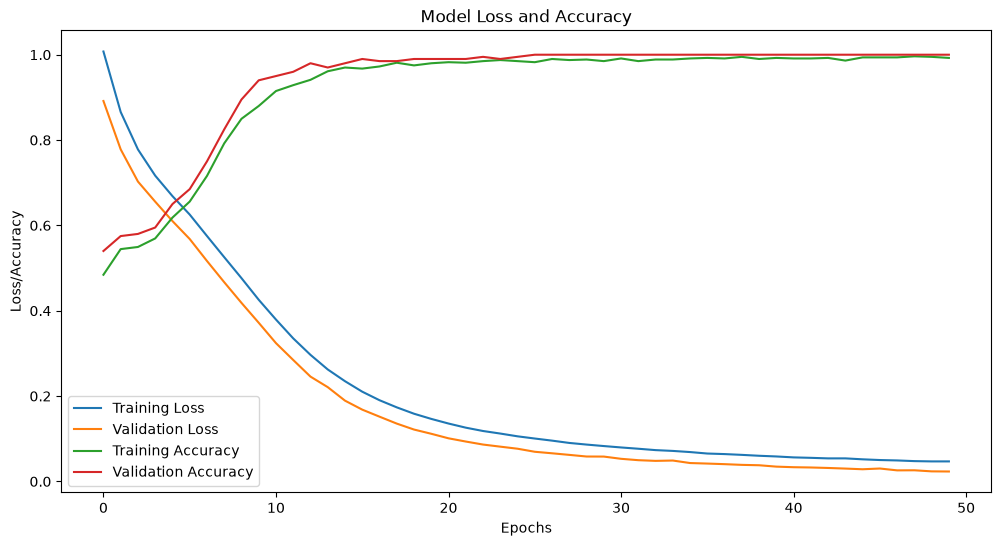

In [15]:
# Plot the training history (helps to determine the number of epochs required)
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Loss and Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss/Accuracy')
plt.legend()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


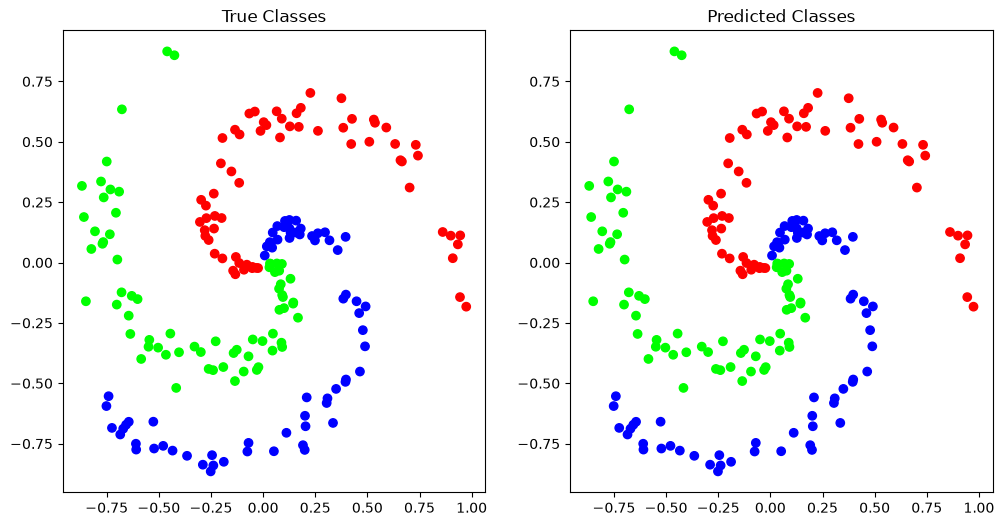

In [16]:
# Predict the class for test data
y_pred = np.argmax(model.predict(X_test_scaled), axis=1)

# Plot the comparison of predictions
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='brg')
plt.title('True Classes')
plt.subplot(1, 2, 2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='brg')
plt.title('Predicted Classes')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


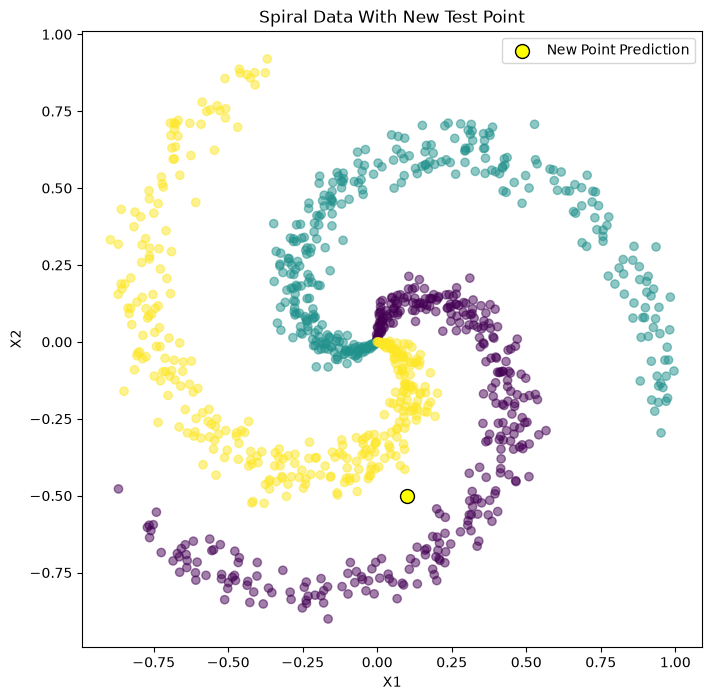

In [18]:
# New Test Point
new_point = np.array([[0.1, -0.5]])
new_point_scaled = scaler.transform(new_point)
new_point_pred = np.argmax(model.predict(new_point_scaled), axis=1)

# Colour the map for the legend
colour_map = {0: 'red', 1: 'green', 2: 'blue'}

# Plot the neww test point prediction
plt.figure(figsize=(8,8))
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.5)
plt.scatter(new_point[:, 0], new_point[:, 1], c='yellow', edgecolors='black', s=100, label=f'New Point Prediction')
plt.title('Spiral Data With New Test Point')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()